**ASSIGNMENT 9 - Effect of PCA on Regression and Classification Models**

NAME : MADUSSREE RAVI

CSE B

DATE : 16-03-2026

3122235001074

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
X = pd.read_csv('X_train.txt', sep='\s+', header=None)
y = pd.read_csv('y_train.txt', sep='\s+', header=None).values.ravel()

# 2. PREPROCESSING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dimensionality Reduction for Visualization (and helping DBSCAN/HAC)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [3]:
# --- 3. K-MEANS & ELBOW METHOD ---
wcss = []
silhouette_avg = []
k_range = range(2, 9)

print("Running K-Means for Table 1...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

Running K-Means for Table 1...


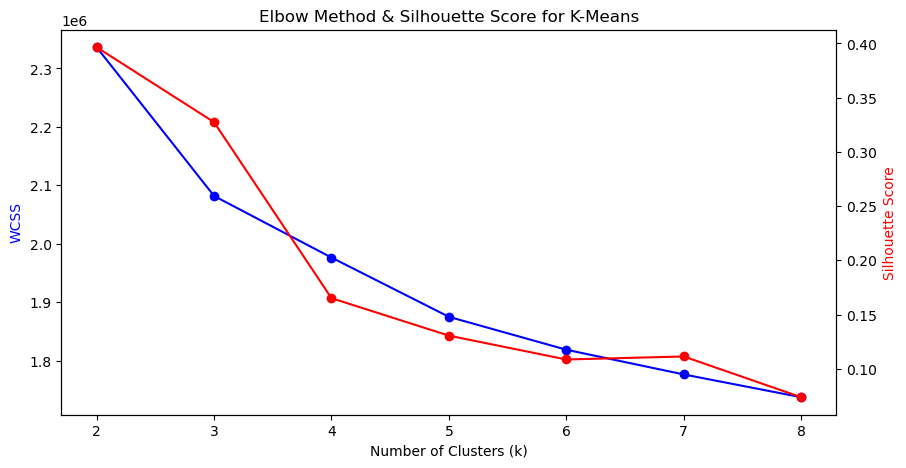

In [4]:
# Plot Elbow and Silhouette Curves
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, wcss, 'bo-', label='WCSS (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS', color='b')
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_avg, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('Elbow Method & Silhouette Score for K-Means')
plt.show()

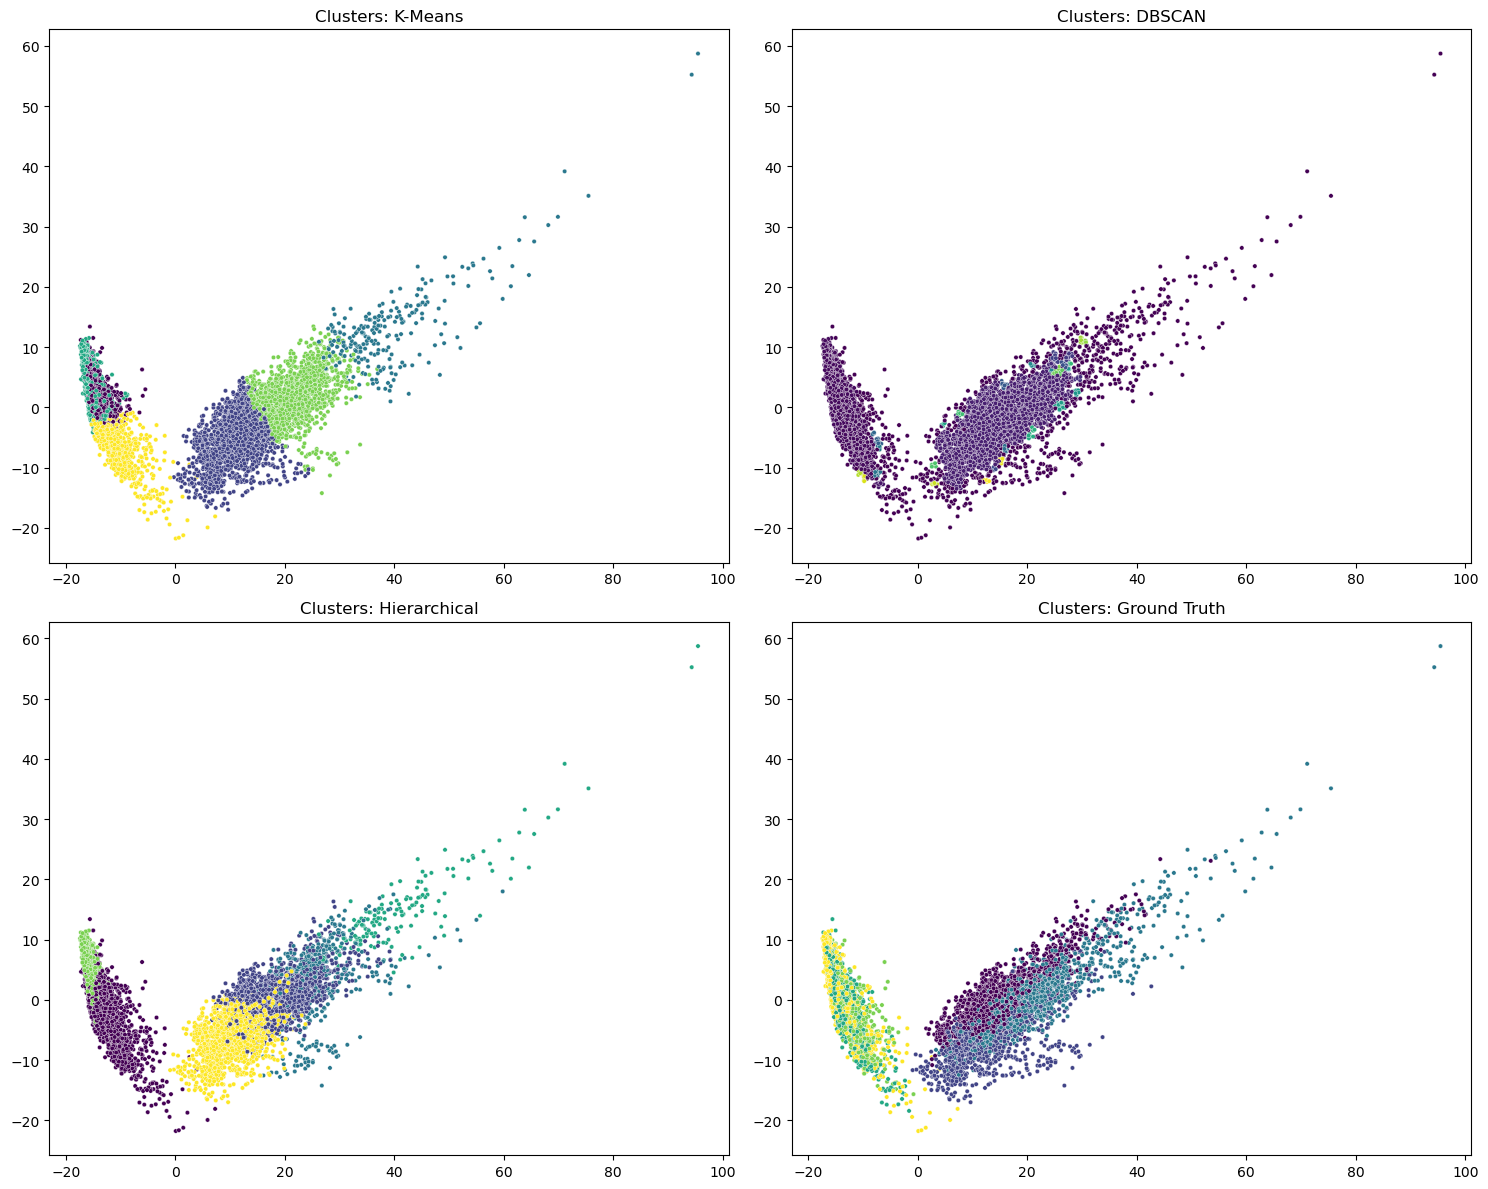

In [5]:
# --- 4. IMPLEMENTING MODELS (Using k=6 based on 6 activities) ---
# Model A: K-Means
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_km = kmeans_final.fit_predict(X_scaled)

# Model B: DBSCAN (Tuned eps for high-dim data or use PCA space)
dbscan = DBSCAN(eps=0.5, min_samples=5) 
labels_db = dbscan.fit_predict(X_pca) # DBSCAN often works better on reduced space

# Model C: Hierarchical (Agglomerative)
hac = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_hac = hac.fit_predict(X_scaled)

# --- 5. VISUALIZATION (PCA Scatter Plots) ---
models = [('K-Means', labels_km), ('DBSCAN', labels_db), ('Hierarchical', labels_hac), ('Ground Truth', y)]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, labels) in enumerate(models):
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='viridis', ax=axes[i], s=10, legend=None)
    axes[i].set_title(f'Clusters: {name}')

plt.tight_layout()
plt.show()

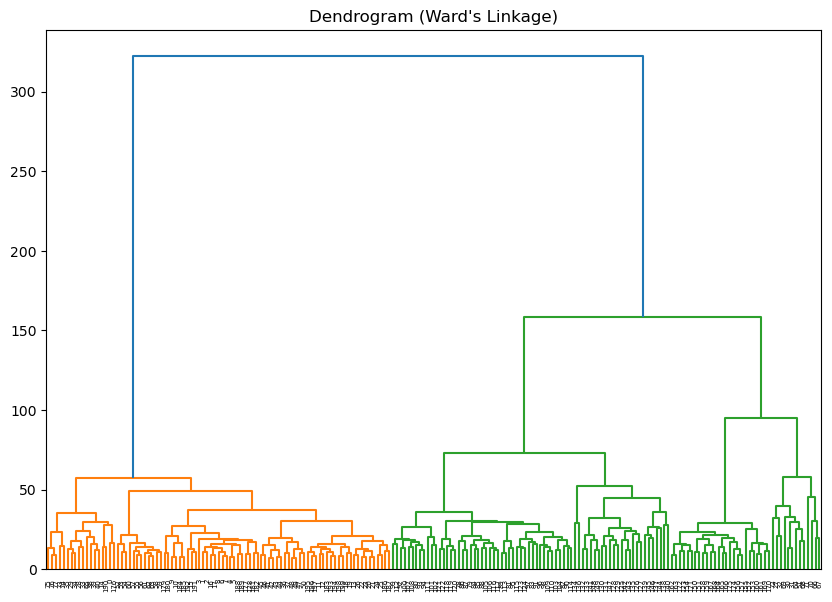


Final Comparative Results:
          Model  Silhouette  DB Index       ARI       NMI
0       K-Means    0.108641  2.357968  0.419714  0.558924
1        DBSCAN   -0.043030  3.610404  0.297846  0.436112
2  Hierarchical    0.083396  2.785733  0.279386  0.454400


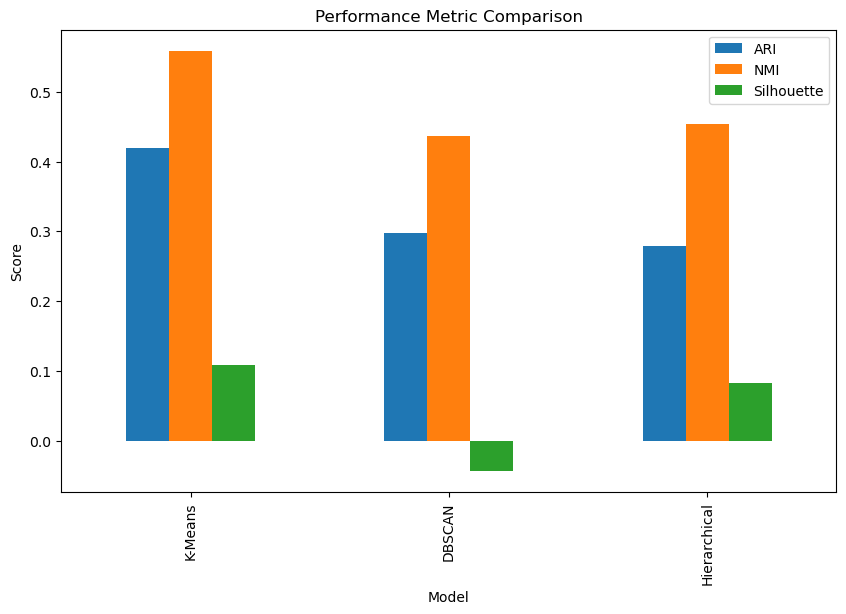

In [6]:
# --- 6. DENDROGRAM (Sub-sample for readability) ---
plt.figure(figsize=(10, 7))
plt.title("Dendrogram (Ward's Linkage)")
linked = linkage(X_scaled[:200], 'ward') # Sample first 200 points for clarity
dendrogram(linked)
plt.show()

# --- 7. EVALUATION METRICS ---
def evaluate(labels, name):
    # Internal
    sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else 0
    db = davies_bouldin_score(X_scaled, labels) if len(set(labels)) > 1 else 0
    # External (Compared to y)
    ari = adjusted_rand_score(y, labels)
    nmi = normalized_mutual_info_score(y, labels)
    return {'Model': name, 'Silhouette': sil, 'DB Index': db, 'ARI': ari, 'NMI': nmi}

results = [evaluate(labels_km, 'K-Means'), evaluate(labels_db, 'DBSCAN'), evaluate(labels_hac, 'Hierarchical')]
df_results = pd.DataFrame(results)
print("\nFinal Comparative Results:")
print(df_results)

# Bar Plot of Metrics
df_results.set_index('Model')[['ARI', 'NMI', 'Silhouette']].plot(kind='bar', figsize=(10, 6))
plt.title('Performance Metric Comparison')
plt.ylabel('Score')
plt.show()